##Data Pipeline (from your document – yfinance / Alpha Vantage)

In [2]:
pip install --upgrade yfinance

## Imports

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")


## WorldQuant-style helper functions

In [4]:
def ts_delta(series, periods=1):
    """Difference between today and N periods ago"""
    return series - series.shift(periods)

def ts_mean(series, window):
    """Rolling mean"""
    return series.rolling(window).mean()


## Download data (KEEP MultiIndex → then reshape)

In [14]:
def download_and_prepare_data(tickers, start, end):
    print("\n=== DOWNLOADING RAW DATA (MultiIndex) ===")
    raw = yf.download(tickers, start=start, end=end)
    print(raw.head())
    print("\nRAW COLUMNS:")
    print(raw.columns)

    print("\n=== CONVERTING TO LONG DATAFRAME ===")
    df = raw['Close'].stack().reset_index()
    df.columns = ['Date', 'Ticker', 'Close']
    df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

    print(df.head(10))
    print("\nTickers found:", df['Ticker'].unique())

    return df


## Add returns correctly (NO apply, NO errors)

In [15]:
def add_returns(df):
    df = df.copy()

    df['returns'] = df.groupby('Ticker')['Close'].transform(
        lambda x: np.log(x / x.shift(1))
    )

    df = df.dropna()

    print("\n=== DATA WITH RETURNS ===")
    print(df.head(10))
    print(df.groupby('Ticker')['returns'].describe())

    return df


## Add sector classification (WorldQuant-style grouping)

In [16]:
def add_sectors(df):
    sector_map = {
        'AAPL': 'Tech',
        'MSFT': 'Tech',
        'KO': 'Consumer',
        'PEP': 'Consumer',
        'XOM': 'Energy'
    }

    df = df.copy()
    df['Sector'] = df['Ticker'].map(sector_map)

    print("\n=== SECTOR ASSIGNMENT ===")
    print(df[['Ticker', 'Sector']].drop_duplicates())

    return df


## Alpha generation (WorldQuant-style)

In [25]:
def add_market_trend_filter(df, start, end):
    print("\n=== ADDING MARKET TREND FILTER (SPY) ===")

    # 1️⃣ Download SPY
    spy = yf.download("SPY", start=start, end=end)

    # 2️⃣ FORCE flat columns (CRITICAL FIX)
    spy = spy[['Close']].copy()
    spy.columns = ['Close']   # remove any MultiIndex ambiguity

    # 3️⃣ Compute MA and trend
    spy['MA200'] = spy['Close'].rolling(200).mean()
    spy['trend_on'] = (spy['Close'] > spy['MA200']).astype(int)

    print("\nSPY trend snapshot:")
    print(spy.tail(10))

    # 4️⃣ Ensure Date alignment
    spy.index = pd.to_datetime(spy.index)
    df['Date'] = pd.to_datetime(df['Date'])

    # 5️⃣ Merge safely
    df = df.merge(
        spy[['trend_on']],
        left_on='Date',
        right_index=True,
        how='left'
    )

    # 6️⃣ Fill missing values
    df['trend_on'] = df['trend_on'].fillna(0).astype(int)

    print("\nTrend filter value counts:")
    print(df['trend_on'].value_counts())

    return df


## Alpha strategy (Improved & filtered)

In [18]:
def alpha_strategy(df, lookback=5, quantile=0.2):
    df = df.copy()

    print("\n=== COMPUTING ALPHA ===")

    # Mean-reversion alpha
    df['delta'] = df.groupby('Ticker')['Close'].transform(
        lambda x: ts_delta(x, lookback)
    )
    df['alpha'] = -df['delta']

    # Rank within sector
    df['rank'] = df.groupby(['Date', 'Sector'])['alpha'].rank(pct=True)

    # Trade only extremes
    df['signal'] = 0
    df.loc[df['rank'] >= 1 - quantile, 'signal'] = 1
    df.loc[df['rank'] <= quantile, 'signal'] = -1

    # Apply market filter (turn OFF during strong trends)
    df['signal'] = df['signal'] * (1 - df['trend_on'])

    # Strategy return (next-day)
    df['strategy_return'] = (
        df['signal'] *
        df.groupby('Ticker')['returns'].shift(-1)
    )

    print("\n=== ALPHA SNAPSHOT ===")
    print(df[['Date', 'Ticker', 'Sector', 'alpha', 'rank', 'signal']].head(15))

    return df.dropna()


## Portfolio aggregation & plotting

In [19]:
def plot_diagnostics(df):
    # Portfolio performance
    portfolio = df.groupby('Date')['strategy_return'].mean()
    market = df.groupby('Date')['returns'].mean()

    plt.figure(figsize=(12, 6))
    np.exp(portfolio.cumsum()).plot(label='Alpha Strategy')
    np.exp(market.cumsum()).plot(label='Market Average')
    plt.title("Alpha Strategy vs Market")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.show()

    # Signal distribution
    plt.figure(figsize=(10, 4))
    df['signal'].value_counts().sort_index().plot(kind='bar')
    plt.title("Signal Distribution")
    plt.xlabel("Signal")
    plt.ylabel("Count")
    plt.show()

    # Trend ON vs OFF
    plt.figure(figsize=(10, 4))
    df.groupby('Date')['trend_on'].mean().plot()
    plt.title("Market Trend Filter (1 = ON, 0 = OFF)")
    plt.ylabel("Trend State")
    plt.show()


## Run everything (main execution)


=== DOWNLOADING RAW DATA (MultiIndex) ===


[*********************100%***********************]  5 of 5 completed


Price          Close                                                  High  \
Ticker          AAPL         KO       MSFT        PEP        XOM      AAPL   
Date                                                                         
2010-01-04  6.418382  17.435406  23.130056  37.962627  37.881798  6.433077   
2010-01-05  6.429481  17.224487  23.137526  38.421352  38.029709  6.465770   
2010-01-06  6.327212  17.218370  22.995535  38.037025  38.358398  6.454974   
2010-01-07  6.315516  17.175583  22.756390  37.795261  38.237881  6.358104   
2010-01-08  6.357502  16.857681  22.913328  37.671272  38.084492  6.358102   

Price                                                   ...      Open  \
Ticker             KO       MSFT        PEP        XOM  ...      AAPL   
Date                                                    ...             
2010-01-04  17.490426  23.242157  38.136198  37.942058  ...  6.400987   
2010-01-05  17.420117  23.242154  38.495740  38.046143  ...  6.436079   
2010-01-06

[*********************100%***********************]  1 of 1 completed



SPY trend snapshot:
                 Close       MA200  trend_on
Date                                        
2024-12-17  595.272644  540.136054         1
2024-12-18  577.531372  540.548989         1
2024-12-19  577.354065  540.948497         1
2024-12-20  584.288635  541.357988         1
2024-12-23  587.787537  541.800051         1
2024-12-24  594.320801  542.276928         1
2024-12-26  594.360352  542.727165         1
2024-12-27  588.103821  543.150072         1
2024-12-30  581.392578  543.544400         1
2024-12-31  579.277405  543.945406         1

Trend filter value counts:
trend_on
1    15130
0     3735
Name: count, dtype: int64

=== COMPUTING ALPHA ===

=== ALPHA SNAPSHOT ===
         Date Ticker Sector     alpha  rank  signal
1  2010-01-05   AAPL   Tech       NaN   NaN       0
2  2010-01-06   AAPL   Tech       NaN   NaN       0
3  2010-01-07   AAPL   Tech       NaN   NaN       0
4  2010-01-08   AAPL   Tech       NaN   NaN       0
5  2010-01-11   AAPL   Tech       NaN   NaN  

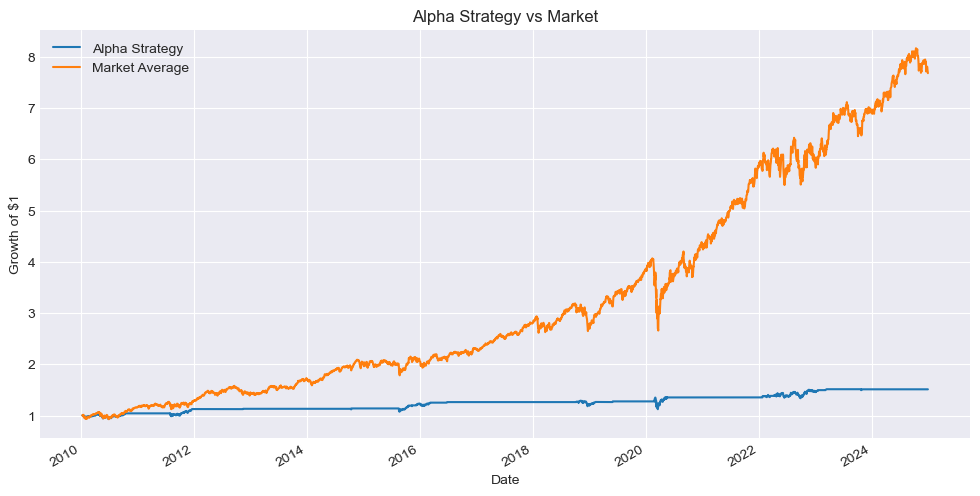

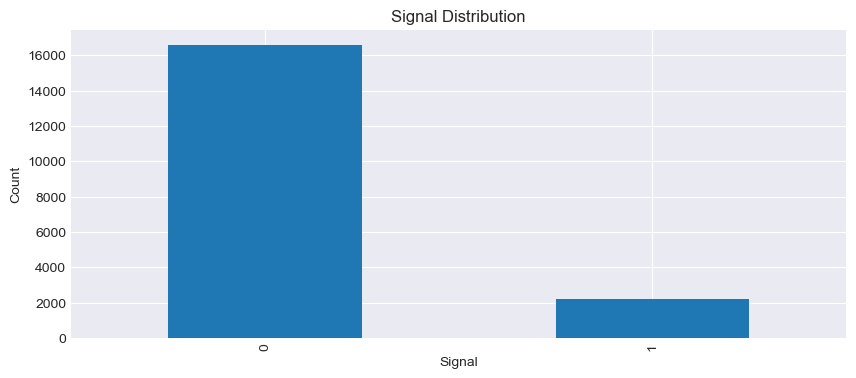

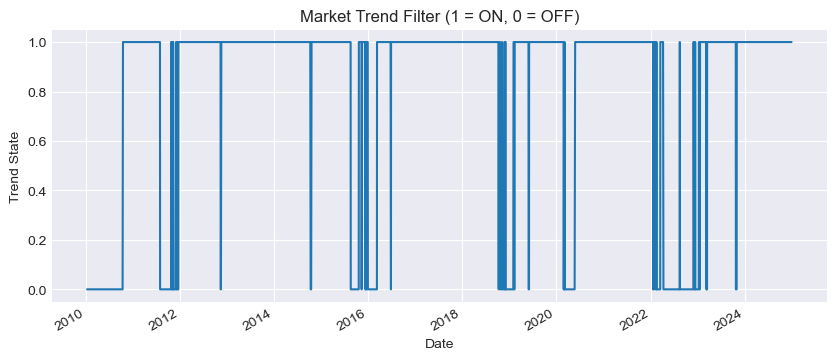

In [27]:
if __name__ == "__main__":

    tickers = ['AAPL', 'MSFT', 'KO', 'PEP', 'XOM']
    start = "2010-01-01"
    end = "2025-01-01"

    df = download_and_prepare_data(tickers, start, end)
    df = add_returns(df)
    df = add_sectors(df)
    df = add_market_trend_filter(df, start, end)
    alpha_df = alpha_strategy(df)
    plot_diagnostics(alpha_df)
